# COGS 189 - Project Checkpoint: Implementing ICA for EEG (Quick CCACSP Sanity Check)

## Authors
- Jya Fan

## Research Question
Does my ICA implementation produce sensible artifact removal on EEG, and how does that affect classification compared to no ICA?

## Background
EEG recordings are often contaminated by non-neural artifacts such as eye movements/blinks and muscle activity. Independent Component Analysis (ICA) is a widely used blind source separation approach that models the observed sensor signals as mixtures of latent sources and can be used to isolate and remove artifact-related components. In motor-imagery EEG classification, a common baseline pipeline is spatial filtering with Common Spatial Patterns (CSP) followed by a linear classifier such as LDA, typically evaluated with cross-validation. In this project, my main focus is implementing an ICA procedure based on the underlying mathematical ideas and using a small, practical experiment to sanity-check its impact on a standard classification task. I also briefly experimented with CCACSP after it was mentioned in class, using it as an additional point of comparison rather than the primary contribution.


1. <a name="cite_note-1"></a> [^](#cite_ref-1)Eunho Noh and Virginia de Sa. "Canonical correlation approach to common spatial patterns." 2013 6th International IEEE/EMBS Conference on Neural Engineering (NER). IEEE, 2013.https://pages.ucsd.edu/~desa/publications/CCACSP.pdf
2. <a name="cite_note-2"></a> [^](#cite_ref-2)Hyvärinen, A., Karhunen, J., & Oja, E. (2001). Independent Component Analysis. John Wiley & Sons.https://www.cs.helsinki.fi/u/ahyvarin/papers/bookfinal_ICA.pdf
3. <a name="cite_note-3"></a>Mahdavi, M. (n.d.). CCACSP [Source code]. GitHub. https://github.com/mahtamsv/CCACSP

## Hypothesis
Removing artifact-related components with ICA may lead to a small but measurable improvement in motor-imagery classification accuracy (CSP+LDA) compared with the same pipeline without ICA, under the same cross-validation setting.

## Data overview (BCI Competition IV, Data set 2a)
- Source: BCI Competition IV – Data set 2a (Graz data set A).
- Paradigm: cue-based motor imagery with four classes (left hand, right hand, feet, tongue).
- Subjects/sessions: 9 subjects; 2 sessions recorded on different days; each session has 6 runs × 48 trials (12 per class), totaling 288 trials per session.
- Modalities/channels: EEG with additional EOG channels; in my loaded file, events were extracted from annotations (603 events; 10 annotation codes present).
- This project: I focused on left vs right motor imagery for a binary classification sanity-check.
- Link: https://www.bbci.de/competition/iv/download/index.html?agree=yes&submit=Submit

## Introduction to ICA algorithm
https://github.com/Fzzz123/COGS189-WI26-Project/blob/main/notebooks/ICA_explaination.ipynb

## Methods

EEG data from the BCI Competition IV dataset 2a were first preprocessed prior to ICA decomposition. The raw recordings were band-pass filtered between 1–60 Hz to remove slow drifts and high-frequency noise while preserving signals relevant for source separation. Electrooculography (EOG) channels were excluded from further analysis. Motor imagery trials corresponding to left- and right-hand conditions were later segmented into epochs from 0.5 s to 2.5 s after cue onset. For classification, an additional band-pass filter of 8–30 Hz was applied to isolate the μ and β rhythms commonly associated with motor imagery.

In [ ]:
raw.drop_channels([ch for ch in ["EOG-left", "EOG-central", "EOG-right"] if ch in raw.ch_names])
raw0 = raw.copy()
raw0._data = raw0._data.copy()

raw_8_30 = raw0.copy()
raw_8_30._data = raw_8_30._data.copy()
raw_8_30.filter(1, 60)
raw_8_30.filter(8, 30)

use = {k: event_id[k] for k in ["769", "770"]}
epochs_o = mne.Epochs(raw_8_30, events, event_id=use, tmin=0.5, tmax=2.5, baseline=None, preload=True)

X = epochs_o.get_data()
y = (epochs_o.events[:, 2] == event_id["770"]).astype(int)

Independent Component Analysis (ICA) was performed using a custom implementation, decomposing the multichannel EEG signal X into statistically independent components according to the linear mixing model X=AS, where S denotes the independent sources and 
𝐴 the mixing matrix. The number of components was set equal to the number of EEG channels (22 components).

In [ ]:
raw_ica = raw0.copy()
raw_ica._data = raw_ica._data.copy()
raw_ica.filter(1, 60)

X = raw_ica.get_data()
S, W, A, mu = icaa(X, n_components=22)

Artifact components were identified using spectral characteristics of each independent component. Power spectral density was computed, and band-power ratios were calculated between low-frequency activity (0.5–4 Hz), high-frequency activity (30–80 Hz), and the μ-band (8–30 Hz). Components exhibiting unusually large low- or high-frequency power relative to the μ-band (top 10% quantile) were classified as artifacts and removed. Clean EEG signals were reconstructed by back-projecting the retained components into sensor space.

In [ ]:
P_mu   = bandpower(psd, freqs, 8, 30)
P_low  = bandpower(psd, freqs, 0.5, 4)
P_high = bandpower(psd, freqs, 30, 80)

low_ratio  = P_low  / (P_mu)
high_ratio = P_high / (P_mu)

bad_low  = np.where(low_ratio  > np.quantile(low_ratio,  0.90))[0]
bad_high = np.where(high_ratio > np.quantile(high_ratio, 0.90))[0]

print("low_ratio top:", np.argsort(low_ratio)[-5:][::-1], low_ratio[np.argsort(low_ratio)[-5:][::-1]])
print("high_ratio top:", np.argsort(high_ratio)[-5:][::-1], high_ratio[np.argsort(high_ratio)[-5:][::-1]])

bad = np.argsort(low_ratio)[-2:][::-1].tolist()

To evaluate the effect of ICA preprocessing, both raw and ICA-cleaned signals were processed using an identical downstream pipeline consisting of Common Spatial Patterns (CSP) feature extraction followed by Linear Discriminant Analysis (LDA) classification with 5-fold stratified cross-validation. This design ensured that performance differences reflected only the impact of ICA-based artifact attenuation.

In [ ]:
clf = Pipeline([
    ("csp", CSP(n_components=6, log=True)),
    ("lda", LDA())
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
X = epochs_o.get_data()
y = epochs_o.events[:, 2]
acc = cross_val_score(clf, X, y, cv=cv).mean()
scores = cross_val_score(clf, X, y, cv=cv)
print(scores, scores.mean(), scores.std())
csp = scores.mean()

## Results

In [2]:
import pandas as pd
df = pd.read_csv("data/results.csv", header=None)
df

,0,1,2,3
0,0.944828,0.944828,0.924138,0.931034
1,0.861330,0.889163,0.882266,0.854680
2,0.597537,0.597291,0.659113,0.652463
3,0.958374,0.972167,0.951478,0.965271
4,0.694828,0.694581,0.666749,0.652956
5,0.611330,0.562562,0.569951,0.528325
6,0.660099,0.708867,0.652709,0.681034
7,0.702463,0.709360,0.736453,0.750493
8,0.965025,0.965025,0.978818,0.971921


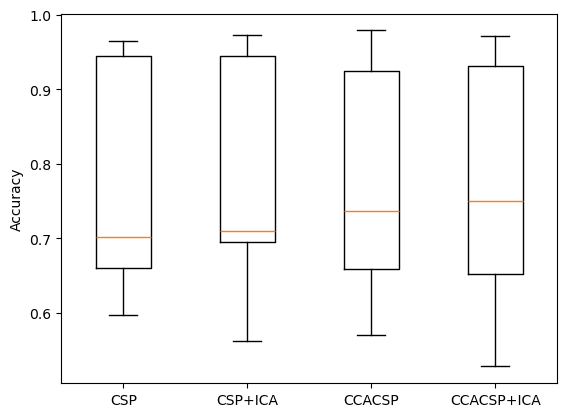

In [4]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot([df[0], df[1], df[2], df[3]], labels=["CSP","CSP+ICA","CCACSP","CCACSP+ICA"])
plt.ylabel("Accuracy")
plt.show()

## Conclusions

With CSP alone, adding ICA generally improves classification accuracy.

On top of CCA-CSP, adding ICA generally has a negative effect.

In some cases, adding ICA can reduce accuracy, because the ICA decomposition can vary across different experimental runs/settings.

It’s unclear why, but the accuracies of CCA-CSP and CSP+ICA are often very similar.